In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("../Dataset/cybersecurity synthesized data.csv")

df


,attack_type,target_system,outcome,timestamp,attacker_ip,target_ip,data_compromised_GB,attack_duration_min,security_tools_used,user_role,location,attack_severity,industry,response_time_min,mitigation_method
0,Phishing,Cloud Service,Failure,2024-04-03 11:13:15.083419,21.166.79.4,23.20.50.78,15.31,300,Firewall,Employee,Australia,2,Energy,164,Containment
1,DDoS,Email Server,Success,2024-02-03 20:51:56.083463,187.180.150.169,34.160.58.218,65.05,242,Endpoint Detection,Admin,Brazil,10,Retail,64,Reset Credentials
2,Zero-Day Exploit,Cloud Service,Success,2024-07-19 18:40:05.083472,57.161.159.140,213.142.125.206,48.99,120,Firewall,External User,Germany,7,Finance,87,Quarantine
3,SQL Injection,Email Server,Failure,2023-12-08 00:54:17.083478,207.108.16.104,4.104.193.49,16.29,286,MFA,Employee,Russia,3,Healthcare,23,Patch
4,Zero-Day Exploit,IoT Device,Failure,2024-07-23 05:38:20.083483,98.122.15.31,57.66.53.194,87.66,4,Firewall,Contractor,UK,6,Finance,129,Containment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Phishing,Network Switch,Success,2024-08-09 10:48:51.650684,71.24.113.116,125.78.245.74,98.99,56,MFA,Employee,Germany,8,Retail,9,Containment
99996,Ransomware,Web Server,Failure,2023-12-19 07:13:23.650687,236.112.108.244,141.23.29.222,87.93,299,WAF,Admin,Australia,4,Healthcare,156,Quarantine
99997,Zero-Day Exploit,API,Success,2024-07-29 07:53:22.650690,4.114.70.4,91.165.90.254,28.23,124,Antivirus,Contractor,Canada,10,Retail,22,Patch
99998,DDoS,User Account,Failure,2024-05-30 11:29:11.650692,91.200.147.68,221.209.161.150,92.38,210,MFA,Admin,India,7,Manufacturing,25,Patch


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df['timestamp'] = pd.to_datetime(df['timestamp'])
sns.set_theme(style="whitegrid")
print(df.shape)
df.dtypes

(100000, 15)


attack_type                       str
target_system                     str
outcome                           str
timestamp              datetime64[us]
attacker_ip                       str
target_ip                         str
data_compromised_GB           float64
attack_duration_min             int64
security_tools_used               str
user_role                         str
location                          str
attack_severity                 int64
industry                          str
response_time_min               int64
mitigation_method                 str
dtype: object

## Categorical Distributions

                      count    pct
attack_type                       
Brute Force           12605  12.60
DDoS                  12557  12.56
Zero-Day Exploit      12555  12.56
Ransomware            12499  12.50
Malware               12469  12.47
SQL Injection         12463  12.46
Phishing              12441  12.44
Cross-Site Scripting  12411  12.41


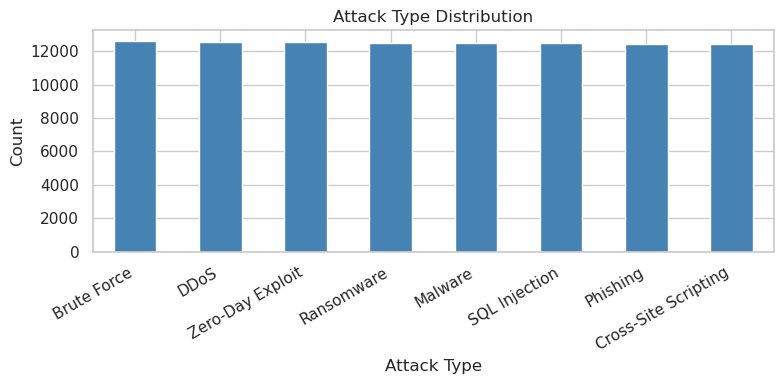

In [7]:
# Attack type breakdown
attack_counts = df['attack_type'].value_counts()
attack_pct = (attack_counts / len(df) * 100).round(2)
attack_summary = pd.DataFrame({'count': attack_counts, 'pct': attack_pct})
print(attack_summary)

fig, ax = plt.subplots(figsize=(8, 4))
attack_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Attack Type Distribution')
ax.set_xlabel('Attack Type')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Overall outcome rate (%):
 outcome
Success    50.03
Failure    49.97
Name: proportion, dtype: float64

Outcome rate by attack type (%):
 outcome               Failure  Success
attack_type                           
Brute Force             49.88    50.12
Cross-Site Scripting    49.54    50.46
DDoS                    49.52    50.48
Malware                 50.02    49.98
Phishing                50.36    49.64
Ransomware              50.27    49.73
SQL Injection           49.88    50.12
Zero-Day Exploit        50.30    49.70


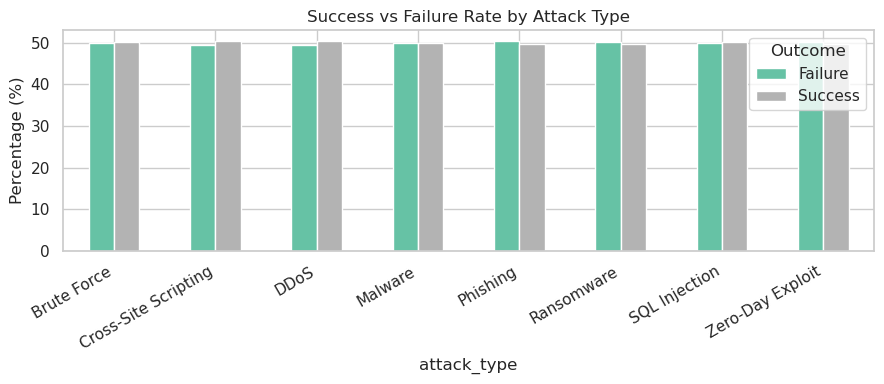

In [8]:
# Outcome rate: overall and per attack type
overall_outcome = df['outcome'].value_counts(normalize=True).mul(100).round(2)
print("Overall outcome rate (%):\n", overall_outcome)

outcome_by_attack = (
    df.groupby('attack_type')['outcome']
    .value_counts(normalize=True)
    .mul(100).round(2)
    .unstack()
)
print("\nOutcome rate by attack type (%):\n", outcome_by_attack)

outcome_by_attack.plot(kind='bar', figsize=(9, 4), colormap='Set2')
plt.title('Success vs Failure Rate by Attack Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()

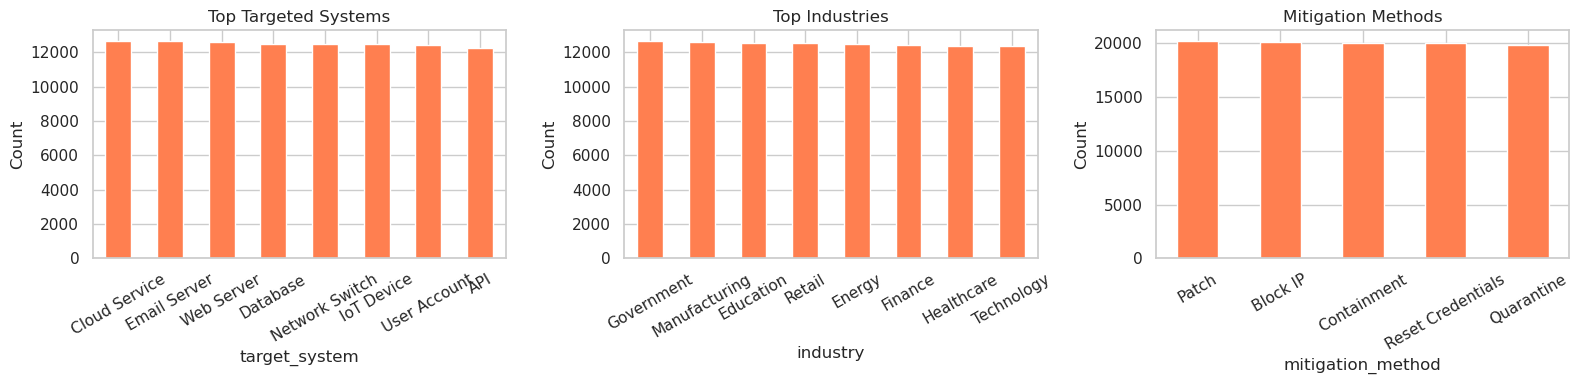

In [9]:
# Top targeted systems, industries, and mitigation methods
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(axes,
                           ['target_system', 'industry', 'mitigation_method'],
                           ['Top Targeted Systems', 'Top Industries', 'Mitigation Methods']):
    df[col].value_counts().plot(kind='bar', ax=ax, color='coral')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Numerical Summaries

In [10]:
# Summary stats for numeric columns
num_cols = ['data_compromised_GB', 'attack_duration_min', 'response_time_min', 'attack_severity']
df[num_cols].describe().round(2)

,data_compromised_GB,attack_duration_min,response_time_min,attack_severity
count,100000.00,100000.00,100000.00,100000.00
mean,50.06,151.07,90.45,5.50
std,28.83,86.73,51.91,2.87
min,0.00,1.00,1.00,1.00
25%,25.17,76.00,46.00,3.00
50%,50.06,151.00,90.00,5.00
75%,74.97,226.00,135.00,8.00
max,100.00,300.00,180.00,10.00


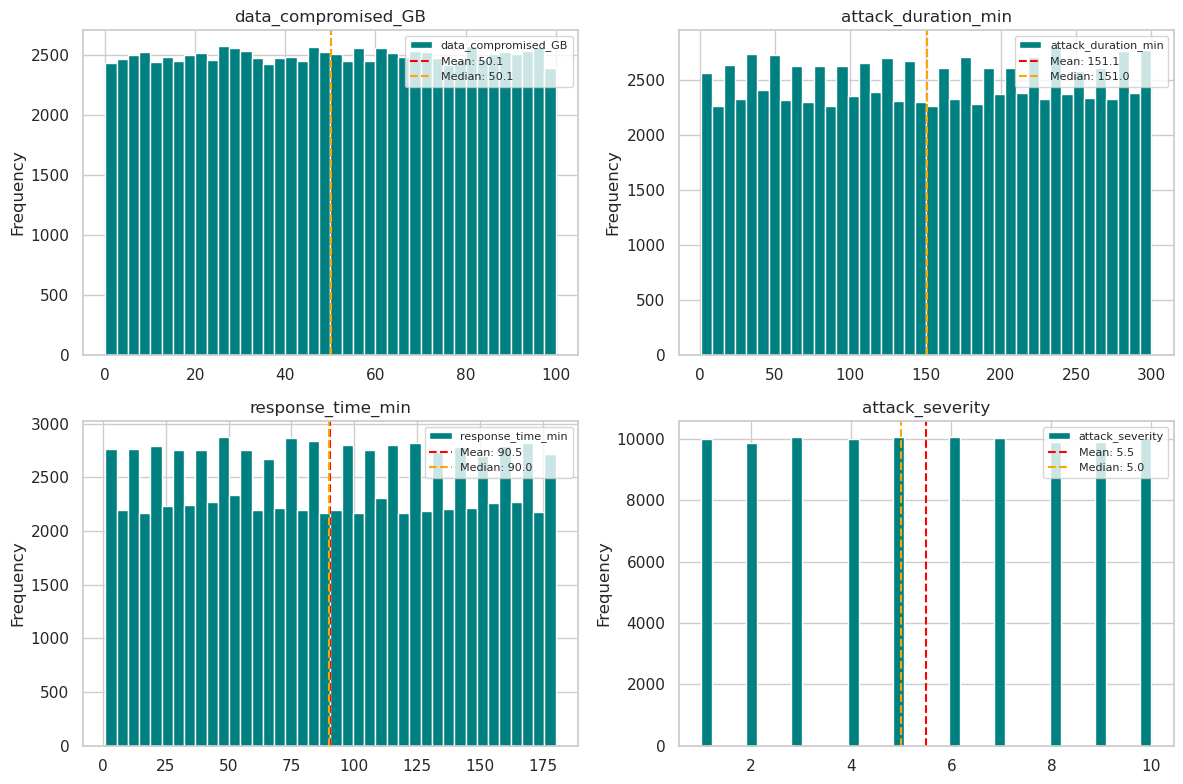

In [11]:
# Distributions of numeric columns
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].plot(kind='hist', bins=40, ax=ax, color='teal', edgecolor='white')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', label=f'Median: {df[col].median():.1f}')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

                       mean  median     max
attack_type                                
Brute Force           49.64   49.75  100.00
Cross-Site Scripting  50.21   49.85   99.99
DDoS                  50.19   50.25  100.00
Malware               49.97   50.00  100.00
Phishing              50.05   50.22   99.97
Ransomware            50.09   50.06   99.99
SQL Injection         50.00   50.08  100.00
Zero-Day Exploit      50.35   50.39  100.00


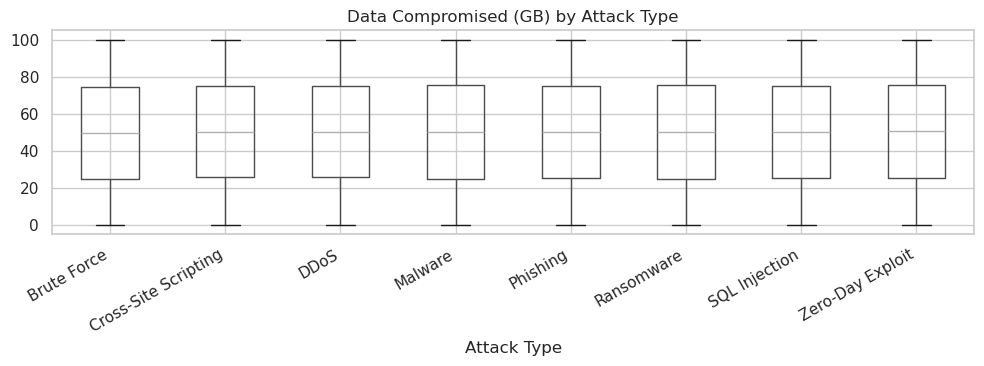

In [12]:
# data_compromised_GB by attack type
gb_by_attack = df.groupby('attack_type')['data_compromised_GB'].agg(['mean', 'median', 'max']).round(2)
print(gb_by_attack)

df.boxplot(column='data_compromised_GB', by='attack_type', figsize=(10, 4))
plt.title('Data Compromised (GB) by Attack Type')
plt.suptitle('')
plt.xlabel('Attack Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Time-Based Analysis

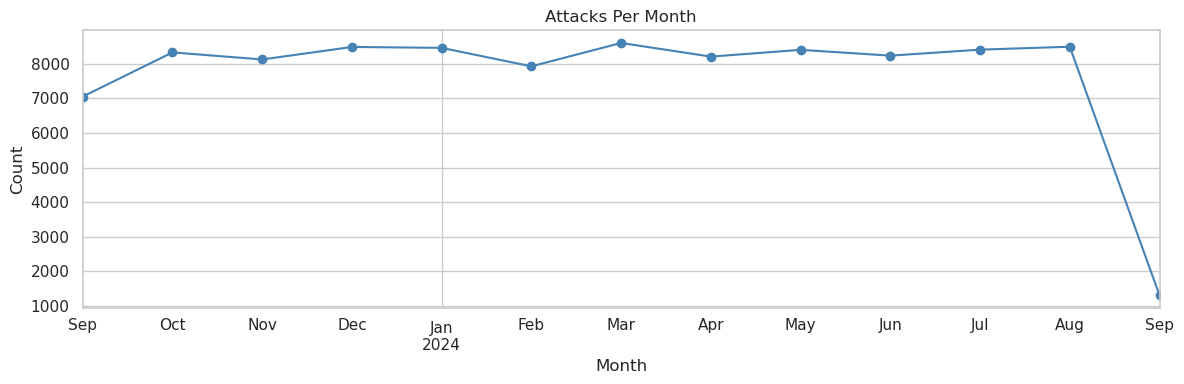

In [13]:
# Attacks per month
monthly = df.set_index('timestamp').resample('ME').size()
monthly.plot(figsize=(12, 4), marker='o', color='steelblue')
plt.title('Attacks Per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

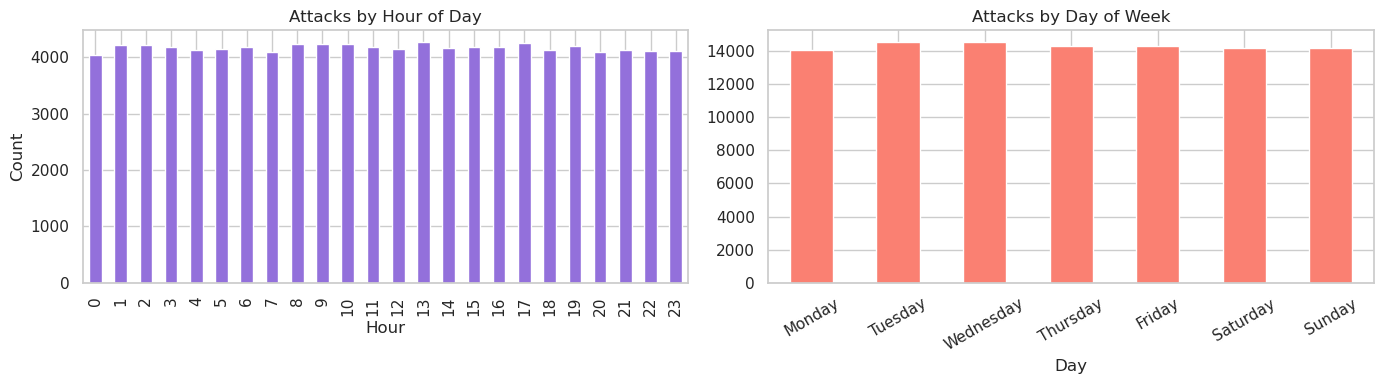

In [14]:
# Peak attack hours and days of week
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='mediumpurple')
axes[0].set_title('Attacks by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day_of_week'].value_counts().reindex(day_order).plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Attacks by Day of Week')
axes[1].set_xlabel('Day')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Geographic Analysis

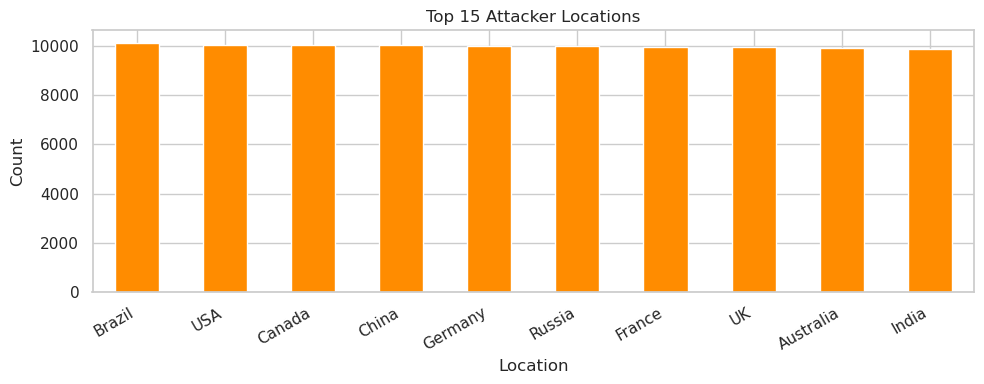

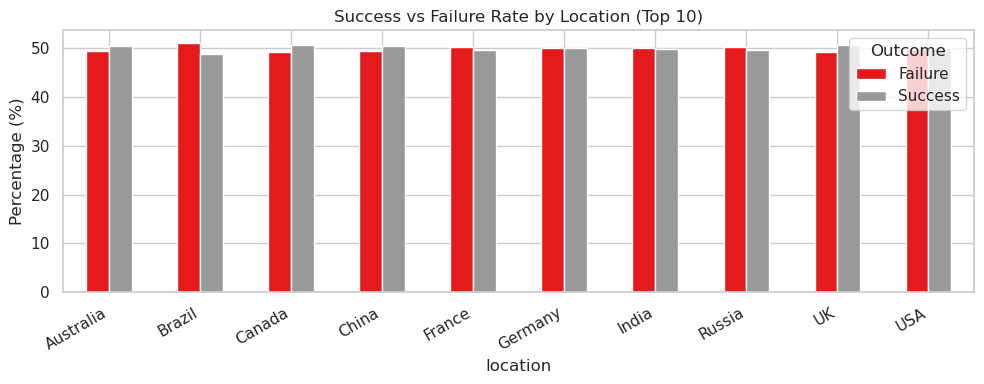

In [15]:
# Top attacker locations
top_locations = df['location'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 4))
top_locations.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Top 15 Attacker Locations')
ax.set_xlabel('Location')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Outcome rate by location (top 10)
top_locs = df['location'].value_counts().head(10).index
outcome_by_loc = (
    df[df['location'].isin(top_locs)]
    .groupby('location')['outcome']
    .value_counts(normalize=True)
    .mul(100).round(2)
    .unstack()
)
outcome_by_loc.plot(kind='bar', figsize=(10, 4), colormap='Set1')
plt.title('Success vs Failure Rate by Location (Top 10)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()

## Correlations & Key Relationships

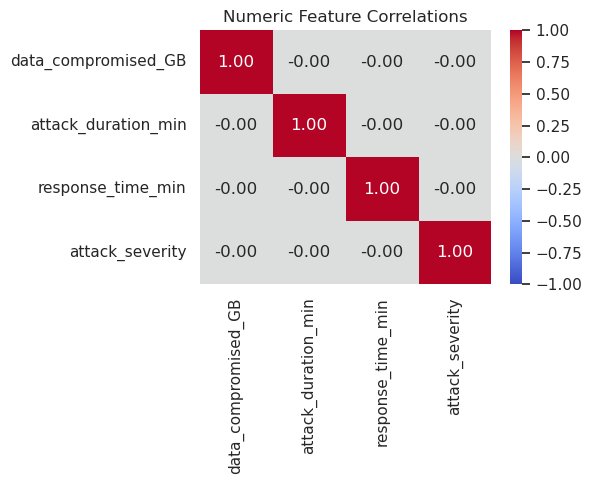

In [16]:
# Correlation heatmap of numeric columns
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
ax.set_title('Numeric Feature Correlations')
plt.tight_layout()
plt.show()

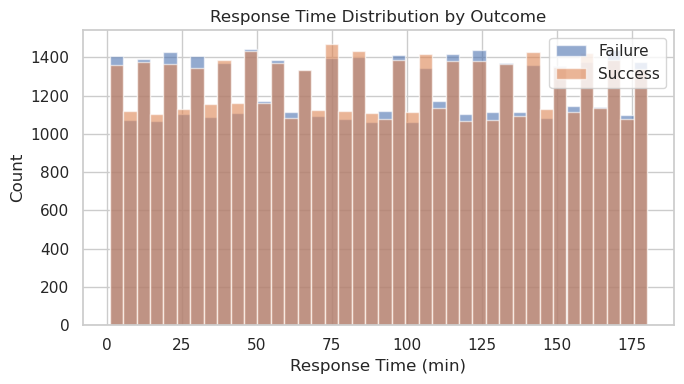

          mean  median
outcome               
Failure  90.57    91.0
Success  90.34    90.0


In [17]:
# Response time vs outcome: does faster response lead to more failures (blocked attacks)?
fig, ax = plt.subplots(figsize=(7, 4))
df.groupby('outcome')['response_time_min'].plot(kind='hist', bins=40, alpha=0.6, ax=ax, legend=True)
ax.set_title('Response Time Distribution by Outcome')
ax.set_xlabel('Response Time (min)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(df.groupby('outcome')['response_time_min'].agg(['mean', 'median']).round(2))

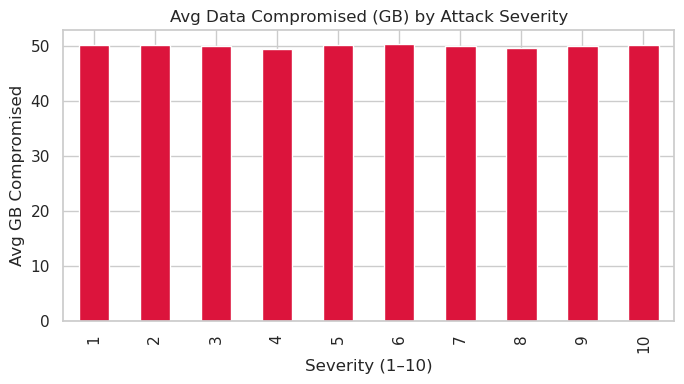

In [18]:
# Attack severity vs data compromised
fig, ax = plt.subplots(figsize=(7, 4))
df.groupby('attack_severity')['data_compromised_GB'].mean().plot(kind='bar', ax=ax, color='crimson')
ax.set_title('Avg Data Compromised (GB) by Attack Severity')
ax.set_xlabel('Severity (1–10)')
ax.set_ylabel('Avg GB Compromised')
plt.tight_layout()
plt.show()

In [ ]:
# Which security tools lead to more failures (i.e., blocked attacks)?
tool_outcome = (
    df.groupby('security_tools_used')['outcome']
    .value_counts(normalize=True)
    .mul(100).round(2)
    .unstack()
)
tool_outcome.sort_values('Failure', ascending=False).plot(kind='bar', figsize=(9, 4), colormap='Set2')
plt.title('Outcome Rate by Security Tool Used')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()